In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from sklearn.model_selection import train_test_split

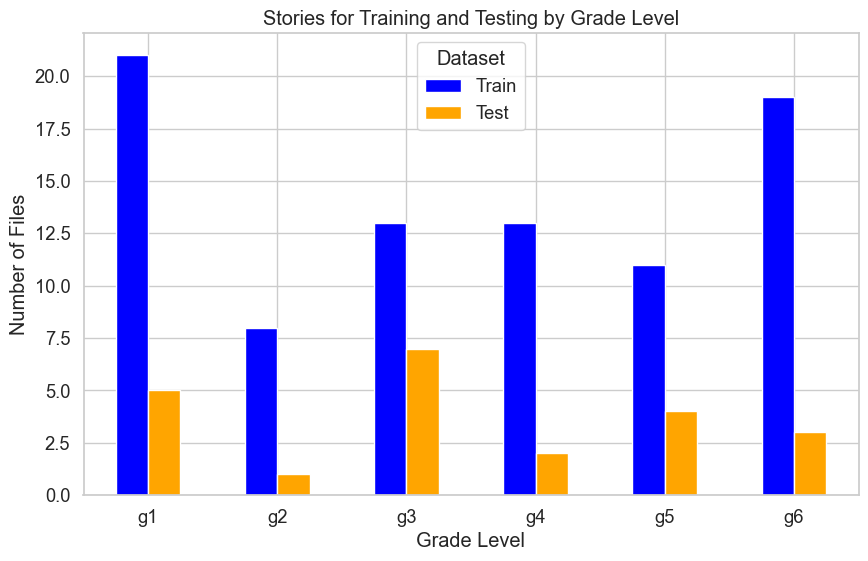

In [53]:
base_dir = "../txt/utf"
test_size=0.2
random_seed=42

all_files = []

for root, _, files in os.walk(base_dir):
    grade = os.path.basename(root)
    for file in files:
        if file.endswith(".txt"):
            all_files.append((os.path.join(root, file), grade))

random.seed(random_seed)
random.shuffle(all_files)
train_files, test_files = train_test_split(all_files, test_size=test_size, random_state=random_seed)

train_grades = [grade for _, grade in train_files]
test_grades = [grade for _, grade in test_files]

train_grade_counts = pd.Series(train_grades).value_counts().sort_index()
test_grade_counts = pd.Series(test_grades).value_counts().sort_index()

grade_data = pd.DataFrame({
    'Train': train_grade_counts,
    'Test': test_grade_counts
}).fillna(0)  # Fill NaN with 0 for missing grade levels

grade_data.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange'])
plt.title('Stories for Training and Testing by Grade Level')
plt.xlabel('Grade Level')
plt.ylabel('Number of Files')
plt.xticks(rotation=0)
plt.legend(title='Dataset')

plt.show()


In [54]:
df = pd.read_csv('../tables/dataset.csv')
df = df.drop(columns=['text_num', 'stride_index', 'n_gram', 'word_num'], axis=1)
df["grade_level"] = df["grade_level"].astype("category")

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
  grade_level  stride_len  noun_tr  verb_tr  type_tr  lex_density  \
0           4         100     0.21     0.17     0.57         0.49   
1           4         100     0.22     0.17     0.57         0.50   
2           4         100     0.21     0.17     0.58         0.50   
3           4         100     0.21     0.16     0.58         0.49   
4           4         100     0.21     0.16     0.59         0.50   

   lex_foreign   sent_len  word_len  syll_num  poly_num  
0          0.0  14.533333      4.51      1.41         6  
1          0.0  14.533333      4.51      1.42         6  
2          0.0  14.533333      4.53      1.44         6  
3          0.0  14.533333      4.52      1.43         6  
4          0.0  14.533333      4.58      1.46         7  


In [55]:
# Feature data type
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55419 entries, 0 to 55418
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   grade_level  55419 non-null  category
 1   stride_len   55419 non-null  int64   
 2   noun_tr      55419 non-null  float64 
 3   verb_tr      55419 non-null  float64 
 4   type_tr      55419 non-null  float64 
 5   lex_density  55419 non-null  float64 
 6   lex_foreign  55419 non-null  float64 
 7   sent_len     55419 non-null  float64 
 8   word_len     55419 non-null  float64 
 9   syll_num     55419 non-null  float64 
 10  poly_num     55419 non-null  int64   
dtypes: category(1), float64(8), int64(2)
memory usage: 4.3 MB
None


In [56]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
grade_level    0
stride_len     0
noun_tr        0
verb_tr        0
type_tr        0
lex_density    0
lex_foreign    0
sent_len       0
word_len       0
syll_num       0
poly_num       0
dtype: int64


In [57]:
# Summary statistics of numerical columns
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       stride_len       noun_tr       verb_tr       type_tr   lex_density  \
count     55419.0  55419.000000  55419.000000  55419.000000  55419.000000   
mean        100.0      0.398392      0.101410      0.547135      0.608821   
std           0.0      0.263808      0.064279      0.198698      0.147755   
min         100.0      0.090000      0.000000      0.140000      0.330000   
25%         100.0      0.230000      0.060000      0.540000      0.510000   
50%         100.0      0.270000      0.120000      0.630000      0.550000   
75%         100.0      0.370000      0.150000      0.680000      0.620000   
max         100.0      0.950000      0.260000      0.910000      0.950000   

        lex_foreign      sent_len      word_len      syll_num      poly_num  
count  55419.000000  55419.000000  55419.000000  55419.000000  55419.000000  
mean       0.005530     23.188424      3.923635      1.315063      7.678504  
std        0.011969     20.030217      1.652683    

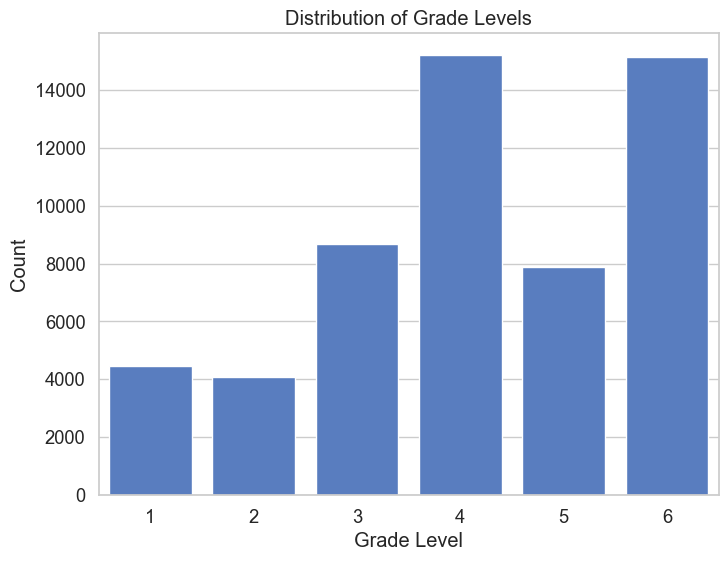

In [58]:
# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
sns.countplot(x='grade_level', data=df)
plt.title('Distribution of Grade Levels')
plt.xlabel('Grade Level')
plt.ylabel('Count')
plt.show()


Grade level counts after undersampling:


/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_2189/1221239987.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_2189/1221239987.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)


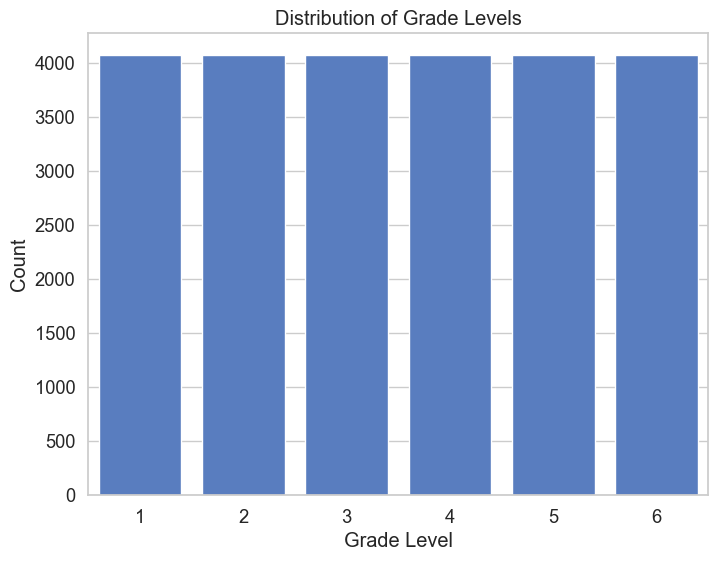

In [59]:
# Undersample the dataset to have an equal number of entries for each grade level
def undersample_dataset(df, grade_column):
    # Find the minimum count of entries across all grade levels
    min_count = df[grade_column].value_counts().min()
    # Group by grade level and sample min_count entries from each group
    undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
    return undersampled_df

# Apply undersampling to the dataset
df_undersampled = undersample_dataset(df, 'grade_level')

# Display the count of entries per grade level after undersampling
print("\nGrade level counts after undersampling:")

# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
sns.countplot(x='grade_level', data=df_undersampled)
plt.title('Distribution of Grade Levels')
plt.xlabel('Grade Level')
plt.ylabel('Count')
plt.show()

In [60]:
df_filtered = df[df['stride_len'] > 3]

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_2189/4271052035.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = database.groupby("grade_level")[feature_cols].mean()


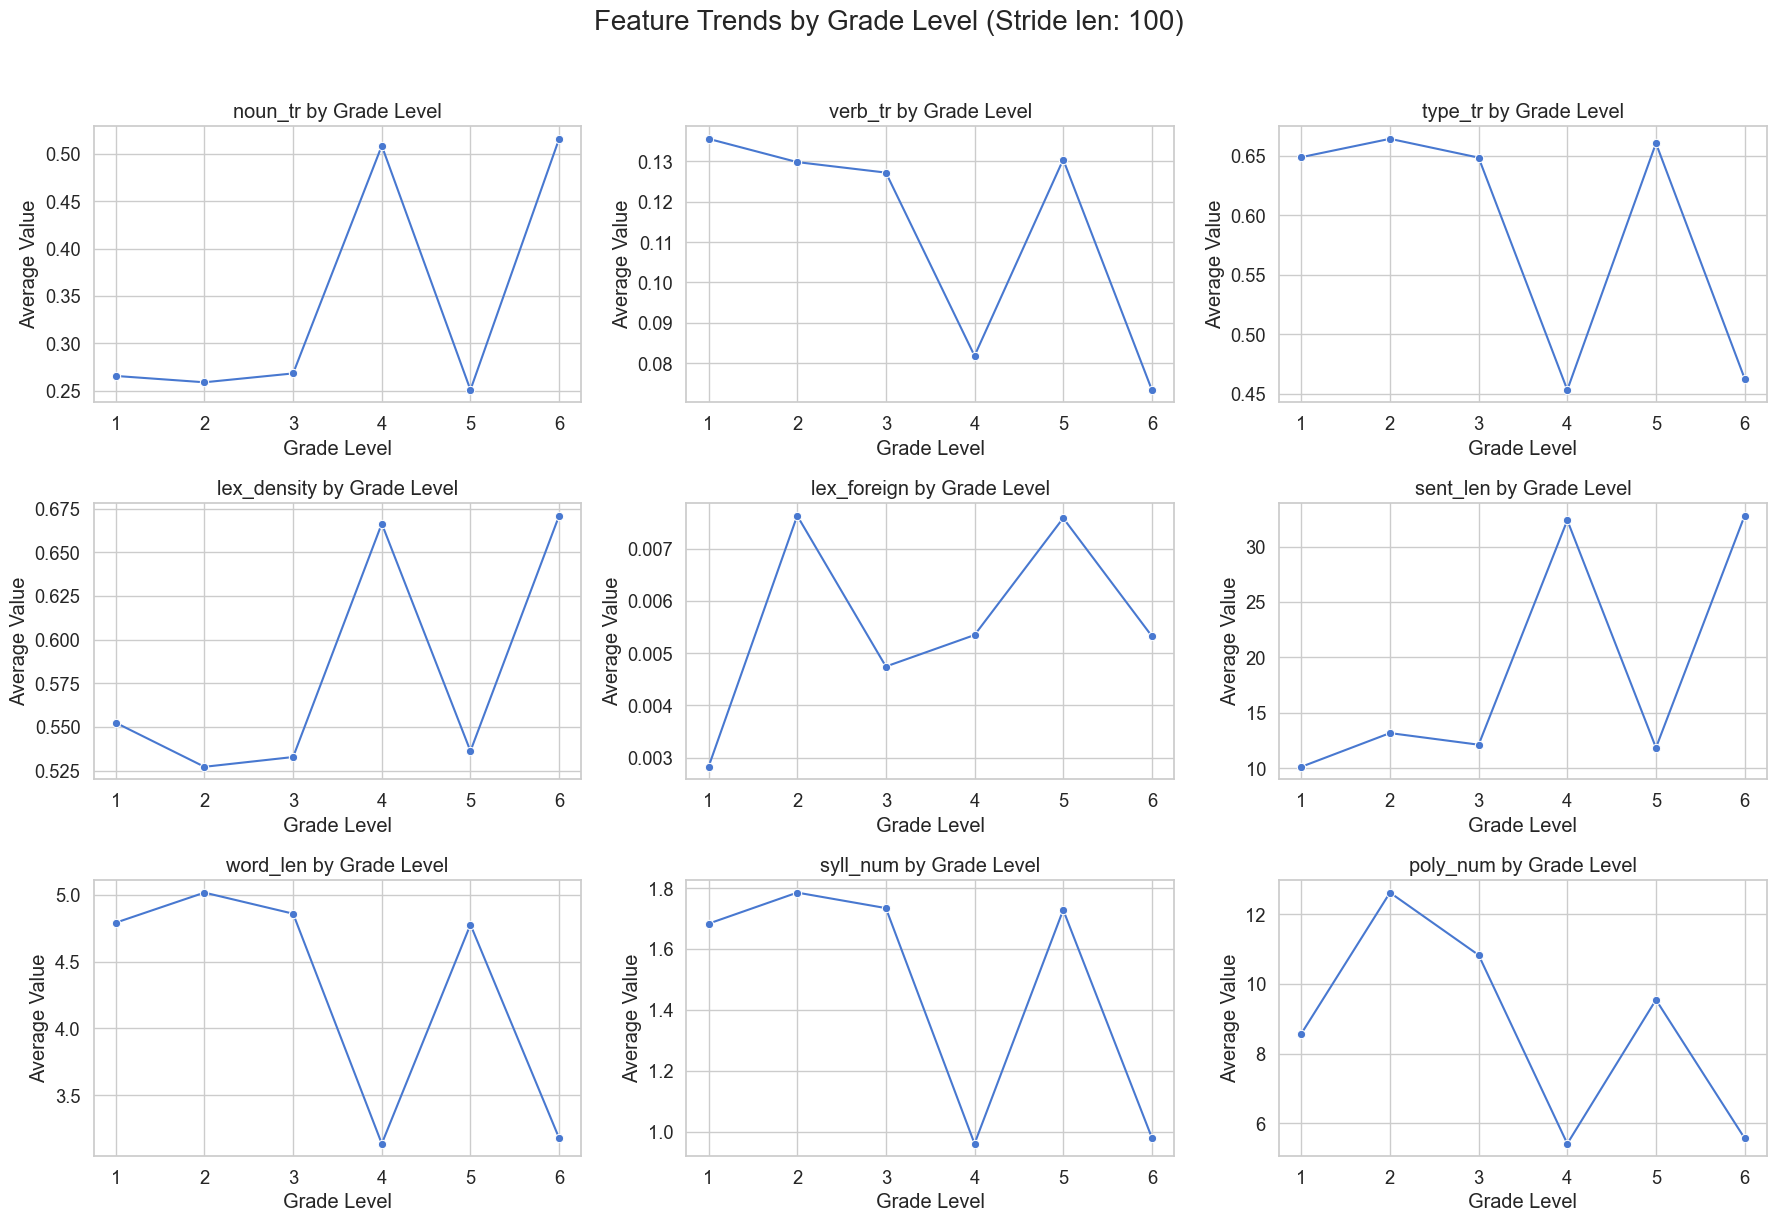

In [62]:
database = df
database_name = "Stride len: 100"

feature_cols = [
    "noun_tr", "verb_tr", "type_tr", "lex_density", "lex_foreign",
    "sent_len", "word_len", "syll_num", "poly_num"
]

# Group by grade_level and compute average feature values
grouped = database.groupby("grade_level")[feature_cols].mean()

# Plot setup
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(grouped.columns):
    sns.lineplot(
        x=grouped.index.astype(str),
        y=grouped[feature],
        marker='o',
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} by Grade Level")
    axes[i].set_xlabel("Grade Level")
    axes[i].set_ylabel("Average Value")

plt.suptitle(f"Feature Trends by Grade Level ({database_name})", y=1.02, fontsize=20)
plt.tight_layout()
plt.show()
